PEAK MOMENT SCATTER PLOT GENERATOR
Model: PyramidAttnCNN RESIDUAL v3
Reading file: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\TruePredDiff.xlsx
Processing KFM (X) data...
  Found 875 KFM samples
Processing KAM (Y) data...
  Found 875 KAM samples

----------------------------------------
Creating KFM scatter plot...
KFM plot saved to: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\peak_scatter_plots\peak_KFM_scatter.png
  R² = 0.115


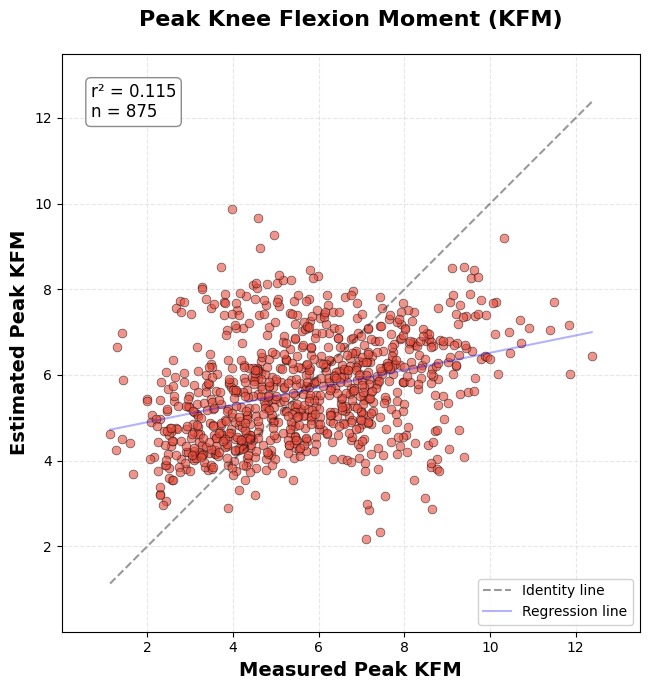


----------------------------------------
Creating KAM scatter plot...
KAM plot saved to: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\peak_scatter_plots\peak_KAM_scatter.png
  R² = 0.377


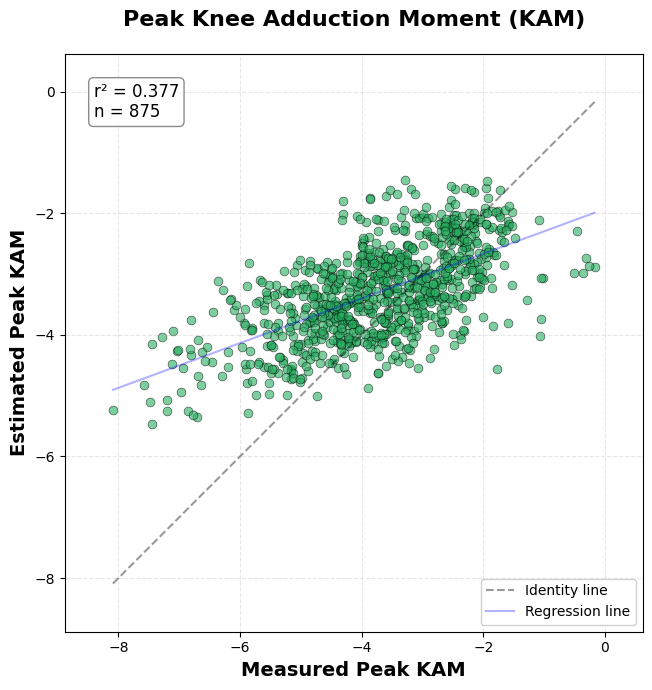


----------------------------------------
Creating combined figure...
Combined plot saved to: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\peak_scatter_plots\peak_moments_combined.png


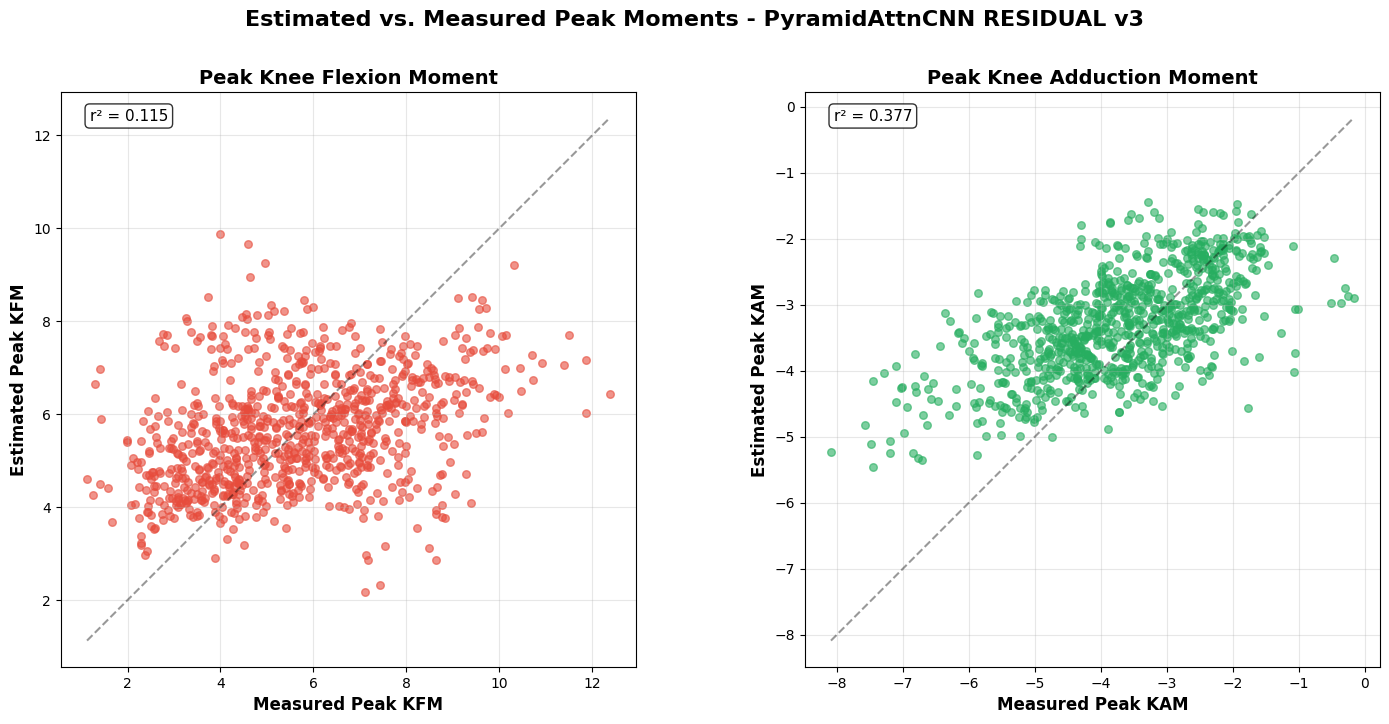


RESULTS SUMMARY
KFM_R2: 0.115
KAM_R2: 0.377

All plots have been saved to: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\peak_scatter_plots


In [5]:
# Peak Moment Scatter Plot Generator for Jupyter Notebook
# This script creates scatter plots comparing measured vs estimated peak moments
# Model: PyramidAttnCNN RESIDUAL v3

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import argrelextrema

# ============================================================================
# CONFIGURATION - MODIFY THIS SECTION
# ============================================================================

# Set your Excel file path here
FILE_PATH = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\TruePredDiff.xlsx"

# Output directory for saving plots
SAVE_DIR = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\peak_scatter_plots"

# Peak detection order (higher = stricter peak detection)
PEAK_ORDER = 20

# Columns to skip (non-data columns in the Excel)
SKIP_COLS = {'Timepoint'}

# ============================================================================
# PEAK DETECTION AND PLOTTING FUNCTIONS
# ============================================================================

def find_peaks_KFM(colData, order=20):
    """Find maximum peaks for KFM (Knee Flexion Moment) data"""
    ilocs_max = argrelextrema(colData.values, np.greater_equal, order=order)
    timing = ilocs_max[0]
    
    if len(timing) >= 1:
        total_peak = colData.iloc[timing]
        max_peak_value = total_peak.max()
        return max_peak_value
    else:
        return np.nan

def find_peaks_KAM(colData, order=20):
    """Find minimum peaks for KAM (Knee Adduction Moment) data"""
    ilocs_min = argrelextrema(colData.values, np.less_equal, order=order)
    timing = ilocs_min[0]
    
    if len(timing) >= 1:
        total_peak = colData.iloc[timing]
        min_peak_value = total_peak.min()
        return min_peak_value
    else:
        return np.nan

def extract_all_peaks(file_path, order=20):
    """Extract peak values from Excel file"""
    
    print(f"Reading file: {file_path}")
    
    # Read all sheets from Excel file
    df_dict = pd.read_excel(file_path, sheet_name=None)
    
    results = {}
    
    # Process KFM (X) data
    if "true_X" in df_dict and "pred_X" in df_dict:
        print("Processing KFM (X) data...")
        
        true_X_peaks = []
        pred_X_peaks = []
        
        # Extract peaks from each column
        for col in df_dict["true_X"].columns:
            if not str(col).startswith('Unnamed') and col != 0 and str(col) not in SKIP_COLS:
                peak_val = find_peaks_KFM(df_dict["true_X"][col], order)
                true_X_peaks.append(peak_val)
        
        for col in df_dict["pred_X"].columns:
            if not str(col).startswith('Unnamed') and col != 0 and str(col) not in SKIP_COLS:
                peak_val = find_peaks_KFM(df_dict["pred_X"][col], order)
                pred_X_peaks.append(peak_val)
        
        results['true_KFM'] = np.array(true_X_peaks)
        results['pred_KFM'] = np.array(pred_X_peaks)
        print(f"  Found {len(true_X_peaks)} KFM samples")
    
    # Process KAM (Y) data
    if "true_Y" in df_dict and "pred_Y" in df_dict:
        print("Processing KAM (Y) data...")
        
        true_Y_peaks = []
        pred_Y_peaks = []
        
        # Extract peaks from each column
        for col in df_dict["true_Y"].columns:
            if not str(col).startswith('Unnamed') and col != 0 and str(col) not in SKIP_COLS:
                peak_val = find_peaks_KAM(df_dict["true_Y"][col], order)
                true_Y_peaks.append(peak_val)
        
        for col in df_dict["pred_Y"].columns:
            if not str(col).startswith('Unnamed') and col != 0 and str(col) not in SKIP_COLS:
                peak_val = find_peaks_KAM(df_dict["pred_Y"][col], order)
                pred_Y_peaks.append(peak_val)
        
        results['true_KAM'] = np.array(true_Y_peaks)
        results['pred_KAM'] = np.array(pred_Y_peaks)
        print(f"  Found {len(true_Y_peaks)} KAM samples")
    
    return results

def create_scatter_plot(measured, estimated, moment_type='KFM'):
    """Create a single scatter plot with R² calculation"""
    
    # Remove NaN values
    valid_mask = ~np.isnan(measured) & ~np.isnan(estimated)
    measured_clean = measured[valid_mask]
    estimated_clean = estimated[valid_mask]
    
    if len(measured_clean) < 2:
        print(f"Warning: Not enough valid data points for {moment_type}")
        return None, 0
    
    # Calculate R²
    slope, intercept, r_value, p_value, std_err = stats.linregress(measured_clean, estimated_clean)
    r_squared = r_value ** 2
    
    # Set colors based on moment type
    if moment_type == 'KFM':
        color = '#e74c3c'  # Red
        title = 'Peak Knee Flexion Moment (KFM)'
    else:  # KAM
        color = '#27ae60'  # Green
        title = 'Peak Knee Adduction Moment (KAM)'
    
    # Create figure
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # Scatter plot
    ax.scatter(measured_clean, estimated_clean, alpha=0.6, color=color, s=40, edgecolors='black', linewidth=0.5)
    
    # Add identity line (y=x)
    min_val = min(measured_clean.min(), estimated_clean.min())
    max_val = max(measured_clean.max(), estimated_clean.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, linewidth=1.5, label='Identity line')
    
    # Add regression line
    x_line = np.array([min_val, max_val])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'b-', alpha=0.3, linewidth=1.5, label=f'Regression line')
    
    # Add R² text box
    textstr = f'r² = {r_squared:.3f}\nn = {len(measured_clean)}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    # Labels and formatting
    ax.set_xlabel(f'Measured Peak {moment_type}', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'Estimated Peak {moment_type}', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('equal', adjustable='box')
    
    # Set equal axis limits with some padding
    all_vals = np.concatenate([measured_clean, estimated_clean])
    margin = (all_vals.max() - all_vals.min()) * 0.1
    lim_min = all_vals.min() - margin
    lim_max = all_vals.max() + margin
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    
    ax.legend(loc='lower right', framealpha=0.9)
    
    plt.tight_layout()
    
    return fig, r_squared

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 60)
print("PEAK MOMENT SCATTER PLOT GENERATOR")
print("Model: PyramidAttnCNN RESIDUAL v3")
print("=" * 60)

# Extract peaks from Excel file
peaks_data = extract_all_peaks(FILE_PATH, PEAK_ORDER)

# Create output directory if it doesn't exist
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"\nCreated output directory: {SAVE_DIR}")

results_summary = {}

# Create KFM scatter plot
if 'true_KFM' in peaks_data and 'pred_KFM' in peaks_data:
    print("\n" + "-" * 40)
    print("Creating KFM scatter plot...")
    fig_kfm, r2_kfm = create_scatter_plot(
        peaks_data['true_KFM'], 
        peaks_data['pred_KFM'], 
        moment_type='KFM'
    )
    
    if fig_kfm:
        # Save figure
        save_path = os.path.join(SAVE_DIR, 'peak_KFM_scatter.png')
        fig_kfm.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"KFM plot saved to: {save_path}")
        print(f"  R² = {r2_kfm:.3f}")
        results_summary['KFM_R2'] = r2_kfm
        plt.show()

# Create KAM scatter plot
if 'true_KAM' in peaks_data and 'pred_KAM' in peaks_data:
    print("\n" + "-" * 40)
    print("Creating KAM scatter plot...")
    fig_kam, r2_kam = create_scatter_plot(
        peaks_data['true_KAM'], 
        peaks_data['pred_KAM'], 
        moment_type='KAM'
    )
    
    if fig_kam:
        # Save figure
        save_path = os.path.join(SAVE_DIR, 'peak_KAM_scatter.png')
        fig_kam.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"KAM plot saved to: {save_path}")
        print(f"  R² = {r2_kam:.3f}")
        results_summary['KAM_R2'] = r2_kam
        plt.show()

# Create combined figure
if 'true_KFM' in peaks_data and 'true_KAM' in peaks_data:
    print("\n" + "-" * 40)
    print("Creating combined figure...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # KFM subplot
    measured_kfm = peaks_data['true_KFM']
    estimated_kfm = peaks_data['pred_KFM']
    valid_kfm = ~np.isnan(measured_kfm) & ~np.isnan(estimated_kfm)
    measured_kfm_clean = measured_kfm[valid_kfm]
    estimated_kfm_clean = estimated_kfm[valid_kfm]
    
    if len(measured_kfm_clean) > 1:
        _, _, r_kfm, _, _ = stats.linregress(measured_kfm_clean, estimated_kfm_clean)
        r2_kfm = r_kfm ** 2
        
        ax1.scatter(measured_kfm_clean, estimated_kfm_clean, alpha=0.6, color='#e74c3c', s=30)
        min_kfm = min(measured_kfm_clean.min(), estimated_kfm_clean.min())
        max_kfm = max(measured_kfm_clean.max(), estimated_kfm_clean.max())
        ax1.plot([min_kfm, max_kfm], [min_kfm, max_kfm], 'k--', alpha=0.4)
        ax1.text(0.05, 0.95, f'r² = {r2_kfm:.3f}', transform=ax1.transAxes, 
                fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax1.set_xlabel('Measured Peak KFM', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Estimated Peak KFM', fontsize=12, fontweight='bold')
        ax1.set_title('Peak Knee Flexion Moment', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.set_aspect('equal')
    
    # KAM subplot
    measured_kam = peaks_data['true_KAM']
    estimated_kam = peaks_data['pred_KAM']
    valid_kam = ~np.isnan(measured_kam) & ~np.isnan(estimated_kam)
    measured_kam_clean = measured_kam[valid_kam]
    estimated_kam_clean = estimated_kam[valid_kam]
    
    if len(measured_kam_clean) > 1:
        _, _, r_kam, _, _ = stats.linregress(measured_kam_clean, estimated_kam_clean)
        r2_kam = r_kam ** 2
        
        ax2.scatter(measured_kam_clean, estimated_kam_clean, alpha=0.6, color='#27ae60', s=30)
        min_kam = min(measured_kam_clean.min(), estimated_kam_clean.min())
        max_kam = max(measured_kam_clean.max(), estimated_kam_clean.max())
        ax2.plot([min_kam, max_kam], [min_kam, max_kam], 'k--', alpha=0.4)
        ax2.text(0.05, 0.95, f'r² = {r2_kam:.3f}', transform=ax2.transAxes, 
                fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax2.set_xlabel('Measured Peak KAM', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Estimated Peak KAM', fontsize=12, fontweight='bold')
        ax2.set_title('Peak Knee Adduction Moment', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')
    
    plt.suptitle('Estimated vs. Measured Peak Moments - PyramidAttnCNN RESIDUAL v3', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save combined figure
    save_path = os.path.join(SAVE_DIR, 'peak_moments_combined.png')
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to: {save_path}")
    plt.show()

# Print summary
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
for key, value in results_summary.items():
    print(f"{key}: {value:.3f}")
print("\nAll plots have been saved to:", SAVE_DIR)
print("=" * 60)

MOMENT IMPULSE SCATTER PLOT GENERATOR
Model: PyramidAttnCNN RESIDUAL v3
- KFM: Integral of positive values only
- KAM: Integral of negative values only
Reading file: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\TruePredDiff.xlsx
Processing KFM (X) impulse data...


C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(colData)
C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(colData)
C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(colData)
C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(colData)
C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:31: Dep

  Found 875 KFM impulse samples
Processing KAM (Y) impulse data...


C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(colData)
C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(colData)
C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(colData)
C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(colData)
C:\Users\asmith8\AppData\Local\Temp\ipykernel_6552\1235116071.py:37: Dep

  Found 875 KAM impulse samples

--- KFM Impulse Diagnostics ---
  True  | min=25.7  max=428.6  mean=170.0  std=65.7
  Pred  | min=82.1  max=306.0  mean=160.8  std=34.0
  IQR bounds (x1.5): [-21.5, 357.6]
  Outliers detected (3 trial(s)):
    Trial '463': true=383.2, pred=149.9
    Trial '823': true=428.6, pred=195.8
    Trial '832': true=425.4, pred=207.9

--- KAM Impulse Diagnostics ---
  True  | min=-356.8  max=-4.0  mean=-171.3  std=59.6
  Pred  | min=-267.9  max=-71.7  mean=-154.0  std=36.5
  IQR bounds (x1.5): [-330.4, -9.5]
  Outliers detected (8 trial(s)):
    Trial '376': true=-341.8, pred=-218.5
    Trial '379': true=-347.4, pred=-213.0
    Trial '381': true=-350.0, pred=-252.8
    Trial '384': true=-356.8, pred=-214.4
    Trial '387': true=-335.8, pred=-207.6
    Trial '390': true=-332.6, pred=-228.4
    Trial '866': true=-4.0, pred=-142.6
    Trial '870': true=-6.2, pred=-144.6

----------------------------------------
Creating KFM impulse scatter plot...
KFM impulse plot s

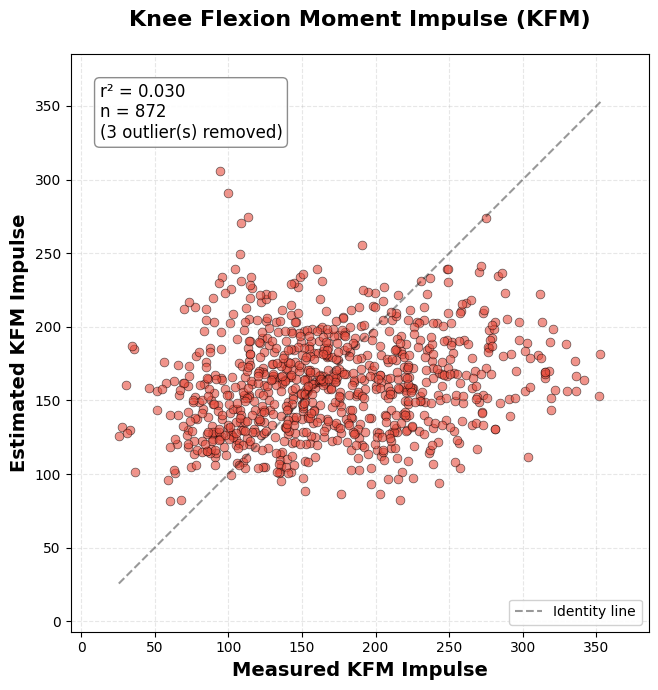


----------------------------------------
Creating KAM impulse scatter plot...
KAM impulse plot saved to: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\impulse_scatter_plots\impulse_KAM_scatter.png
  R² = 0.319


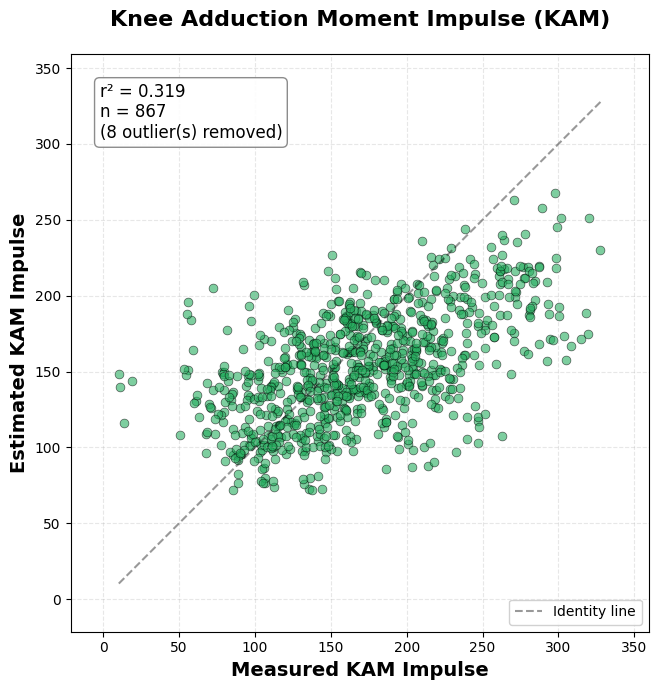


----------------------------------------
Creating combined impulse figure...
Combined impulse plot saved to: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\impulse_scatter_plots\impulse_combined.png


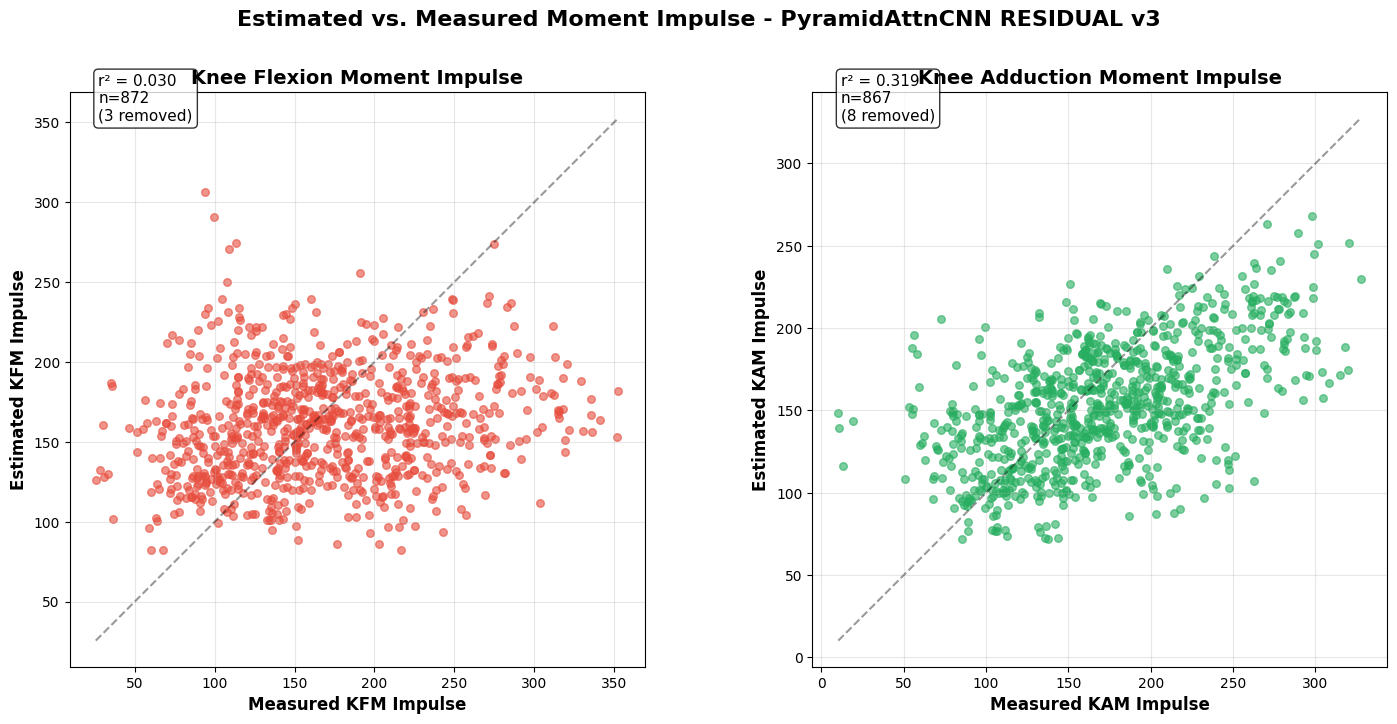


IMPULSE RESULTS SUMMARY
KFM_Impulse_R2: 0.030
KAM_Impulse_R2: 0.319

All plots have been saved to: R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\impulse_scatter_plots


In [6]:
# Impulse Scatter Plot Script
# Model: PyramidAttnCNN RESIDUAL v3

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================================
# CONFIGURATION
# ============================================================================

FILE_PATH = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\TruePredDiff.xlsx"
SAVE_DIR = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\momentpyramidCNN_RESIDUAL_v3\IWALQQ_1st_correction\moBWHT\impulse_scatter_plots"

# IQR multiplier for outlier removal (1.5 = standard, 3.0 = only extreme outliers)
IQR_MULTIPLIER = 1.5

# Columns to skip (non-data columns in the Excel)
SKIP_COLS = {'Timepoint'}

# ============================================================================
# IMPULSE CALCULATION
# ============================================================================

def cal_impulse_X(colData):
    """Calculate impulse for KFM - positive values only"""
    colData = colData.copy()
    colData[colData < 0] = 0  # Only positive values
    return np.trapz(colData)

def cal_impulse_Y(colData):
    """Calculate impulse for KAM - negative values only"""
    colData = colData.copy()
    colData[colData > 0] = 0  # Only negative values
    return np.trapz(colData)

def extract_all_impulses(file_path):
    """Extract impulse values from Excel file, tracking column labels for diagnostics"""
    
    print(f"Reading file: {file_path}")
    
    # Read all sheets from Excel file
    df_dict = pd.read_excel(file_path, sheet_name=None, engine="openpyxl")
    
    results = {}
    
    # Process KFM (X) data - POSITIVE VALUES ONLY
    if "true_X" in df_dict and "pred_X" in df_dict:
        print("Processing KFM (X) impulse data...")
        
        true_X_impulse = []
        pred_X_impulse = []
        col_labels = []
        
        for col in df_dict["true_X"].columns:
            if not str(col).startswith('Unnamed') and col != 0 and str(col) not in SKIP_COLS:
                impulse_val = cal_impulse_X(df_dict["true_X"][col])
                true_X_impulse.append(impulse_val)
                col_labels.append(col)
        
        for col in df_dict["pred_X"].columns:
            if not str(col).startswith('Unnamed') and col != 0 and str(col) not in SKIP_COLS:
                impulse_val = cal_impulse_X(df_dict["pred_X"][col])
                pred_X_impulse.append(impulse_val)
        
        results['true_KFM_impulse'] = np.array(true_X_impulse)
        results['pred_KFM_impulse'] = np.array(pred_X_impulse)
        results['col_labels_KFM'] = col_labels
        print(f"  Found {len(true_X_impulse)} KFM impulse samples")
    
    # Process KAM (Y) data - NEGATIVE VALUES ONLY
    if "true_Y" in df_dict and "pred_Y" in df_dict:
        print("Processing KAM (Y) impulse data...")
        
        true_Y_impulse = []
        pred_Y_impulse = []
        col_labels_y = []
        
        for col in df_dict["true_Y"].columns:
            if not str(col).startswith('Unnamed') and col != 0 and str(col) not in SKIP_COLS:
                impulse_val = cal_impulse_Y(df_dict["true_Y"][col])
                true_Y_impulse.append(impulse_val)
                col_labels_y.append(col)
        
        for col in df_dict["pred_Y"].columns:
            if not str(col).startswith('Unnamed') and col != 0 and str(col) not in SKIP_COLS:
                impulse_val = cal_impulse_Y(df_dict["pred_Y"][col])
                pred_Y_impulse.append(impulse_val)
        
        results['true_KAM_impulse'] = np.array(true_Y_impulse)
        results['pred_KAM_impulse'] = np.array(pred_Y_impulse)
        results['col_labels_KAM'] = col_labels_y
        print(f"  Found {len(true_Y_impulse)} KAM impulse samples")
    
    return results

def diagnose_and_remove_outliers(true_vals, pred_vals, col_labels, label='KFM', iqr_mult=1.5):
    """Print outlier diagnostics and return cleaned arrays with outliers removed."""
    
    print(f"\n--- {label} Impulse Diagnostics ---")
    print(f"  True  | min={true_vals.min():.1f}  max={true_vals.max():.1f}  mean={true_vals.mean():.1f}  std={true_vals.std():.1f}")
    print(f"  Pred  | min={pred_vals.min():.1f}  max={pred_vals.max():.1f}  mean={pred_vals.mean():.1f}  std={pred_vals.std():.1f}")
    
    # IQR on true values to find outlier trials
    q1, q3 = np.percentile(true_vals, [25, 75])
    iqr = q3 - q1
    lower = q1 - iqr_mult * iqr
    upper = q3 + iqr_mult * iqr
    print(f"  IQR bounds (x{iqr_mult}): [{lower:.1f}, {upper:.1f}]")
    
    outlier_mask = (true_vals < lower) | (true_vals > upper)
    if outlier_mask.any():
        print(f"  Outliers detected ({outlier_mask.sum()} trial(s)):")
        for i, is_out in enumerate(outlier_mask):
            if is_out:
                lbl = col_labels[i] if i < len(col_labels) else i
                print(f"    Trial '{lbl}': true={true_vals[i]:.1f}, pred={pred_vals[i]:.1f}")
    else:
        print("  No outliers detected.")
    
    keep = ~outlier_mask
    return true_vals[keep], pred_vals[keep], outlier_mask.sum()

def create_scatter_plot(measured, estimated, moment_type='KFM', n_removed=0):
    """Create scatter plot for impulse data"""
    
    # Remove NaN values
    valid_mask = ~np.isnan(measured) & ~np.isnan(estimated)
    measured_clean = measured[valid_mask]
    estimated_clean = estimated[valid_mask]
    
    # For KAM, convert to absolute values for visualization
    if moment_type == 'KAM':
        measured_clean = np.abs(measured_clean)
        estimated_clean = np.abs(estimated_clean)
    
    if len(measured_clean) < 2:
        print(f"Warning: Not enough valid data points for {moment_type}")
        return None, 0
    
    # Calculate R²
    slope, intercept, r_value, p_value, std_err = stats.linregress(measured_clean, estimated_clean)
    r_squared = r_value ** 2
    
    # Set colors based on moment type
    if moment_type == 'KFM':
        color = '#e74c3c'  # Red
        title = 'Knee Flexion Moment Impulse (KFM)'
    else:  # KAM
        color = '#27ae60'  # Green
        title = 'Knee Adduction Moment Impulse (KAM)'
    
    # Create figure
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # Scatter plot
    ax.scatter(measured_clean, estimated_clean, alpha=0.6, color=color, s=40, 
               edgecolors='black', linewidth=0.5)
    
    # Add identity line (y=x)
    min_val = min(measured_clean.min(), estimated_clean.min())
    max_val = max(measured_clean.max(), estimated_clean.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, 
            linewidth=1.5, label='Identity line')
    
    # Add R² text box (note if outliers were removed)
    removed_note = f'\n({n_removed} outlier(s) removed)' if n_removed > 0 else ''
    textstr = f'r² = {r_squared:.3f}\nn = {len(measured_clean)}{removed_note}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    # Labels and formatting
    ax.set_xlabel(f'Measured {moment_type} Impulse', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'Estimated {moment_type} Impulse', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('equal', adjustable='box')
    
    # Set equal axis limits with some padding
    all_vals = np.concatenate([measured_clean, estimated_clean])
    margin = (all_vals.max() - all_vals.min()) * 0.1
    lim_min = all_vals.min() - margin
    lim_max = all_vals.max() + margin
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    
    ax.legend(loc='lower right', framealpha=0.9)
    
    plt.tight_layout()
    
    return fig, r_squared

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 60)
print("MOMENT IMPULSE SCATTER PLOT GENERATOR")
print("Model: PyramidAttnCNN RESIDUAL v3")
print("- KFM: Integral of positive values only")
print("- KAM: Integral of negative values only")
print("=" * 60)

# Extract impulses from Excel file
impulse_data = extract_all_impulses(FILE_PATH)

# Diagnose and remove outliers
true_kfm_clean, pred_kfm_clean, n_removed_kfm = diagnose_and_remove_outliers(
    impulse_data['true_KFM_impulse'], impulse_data['pred_KFM_impulse'],
    impulse_data.get('col_labels_KFM', []), label='KFM', iqr_mult=IQR_MULTIPLIER
)
true_kam_clean, pred_kam_clean, n_removed_kam = diagnose_and_remove_outliers(
    impulse_data['true_KAM_impulse'], impulse_data['pred_KAM_impulse'],
    impulse_data.get('col_labels_KAM', []), label='KAM', iqr_mult=IQR_MULTIPLIER
)

# Create output directory if it doesn't exist
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"\nCreated output directory: {SAVE_DIR}")

results_summary = {}

# Create KFM impulse scatter plot
print("\n" + "-" * 40)
print("Creating KFM impulse scatter plot...")
fig_kfm, r2_kfm = create_scatter_plot(true_kfm_clean, pred_kfm_clean, moment_type='KFM', n_removed=n_removed_kfm)
if fig_kfm:
    save_path = os.path.join(SAVE_DIR, 'impulse_KFM_scatter.png')
    fig_kfm.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"KFM impulse plot saved to: {save_path}")
    print(f"  R² = {r2_kfm:.3f}")
    results_summary['KFM_Impulse_R2'] = r2_kfm
    plt.show()

# Create KAM impulse scatter plot
print("\n" + "-" * 40)
print("Creating KAM impulse scatter plot...")
fig_kam, r2_kam = create_scatter_plot(true_kam_clean, pred_kam_clean, moment_type='KAM', n_removed=n_removed_kam)
if fig_kam:
    save_path = os.path.join(SAVE_DIR, 'impulse_KAM_scatter.png')
    fig_kam.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"KAM impulse plot saved to: {save_path}")
    print(f"  R² = {r2_kam:.3f}")
    results_summary['KAM_Impulse_R2'] = r2_kam
    plt.show()

# Create combined figure
print("\n" + "-" * 40)
print("Creating combined impulse figure...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# KFM subplot
valid_kfm = ~np.isnan(true_kfm_clean) & ~np.isnan(pred_kfm_clean)
m_kfm = true_kfm_clean[valid_kfm]
e_kfm = pred_kfm_clean[valid_kfm]
if len(m_kfm) > 1:
    _, _, r_kfm, _, _ = stats.linregress(m_kfm, e_kfm)
    r2_kfm = r_kfm ** 2
    ax1.scatter(m_kfm, e_kfm, alpha=0.6, color='#e74c3c', s=30)
    ax1.plot([m_kfm.min(), m_kfm.max()], [m_kfm.min(), m_kfm.max()], 'k--', alpha=0.4)
    removed_note = f'\n({n_removed_kfm} removed)' if n_removed_kfm > 0 else ''
    ax1.text(0.05, 0.95, f'r² = {r2_kfm:.3f}\nn={len(m_kfm)}{removed_note}', transform=ax1.transAxes,
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax1.set_xlabel('Measured KFM Impulse', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Estimated KFM Impulse', fontsize=12, fontweight='bold')
    ax1.set_title('Knee Flexion Moment Impulse', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')

# KAM subplot (convert to absolute for display)
valid_kam = ~np.isnan(true_kam_clean) & ~np.isnan(pred_kam_clean)
m_kam = np.abs(true_kam_clean[valid_kam])
e_kam = np.abs(pred_kam_clean[valid_kam])
if len(m_kam) > 1:
    _, _, r_kam, _, _ = stats.linregress(m_kam, e_kam)
    r2_kam = r_kam ** 2
    ax2.scatter(m_kam, e_kam, alpha=0.6, color='#27ae60', s=30)
    ax2.plot([m_kam.min(), m_kam.max()], [m_kam.min(), m_kam.max()], 'k--', alpha=0.4)
    removed_note = f'\n({n_removed_kam} removed)' if n_removed_kam > 0 else ''
    ax2.text(0.05, 0.95, f'r² = {r2_kam:.3f}\nn={len(m_kam)}{removed_note}', transform=ax2.transAxes,
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax2.set_xlabel('Measured KAM Impulse', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Estimated KAM Impulse', fontsize=12, fontweight='bold')
    ax2.set_title('Knee Adduction Moment Impulse', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')

plt.suptitle('Estimated vs. Measured Moment Impulse - PyramidAttnCNN RESIDUAL v3', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, 'impulse_combined.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Combined impulse plot saved to: {save_path}")
plt.show()

# Print summary
print("\n" + "=" * 60)
print("IMPULSE RESULTS SUMMARY")
print("=" * 60)
for key, value in results_summary.items():
    print(f"{key}: {value:.3f}")
print("\nAll plots have been saved to:", SAVE_DIR)
print("=" * 60)